**Summary**
---
This project demonstrates the application of Random Forest Regression and Linear Regression to predict car resale prices. <br> 
While Linear Regression provides a simple baseline, the Random Forest model proves far more effective, capturing complex, non‑linear relationships across multiple features such as mileage, age, fuel type, seller type, and transmission. <br>
The model not only achieves higher predictive accuracy but also offers interpretability through feature importance and SHAP analysis, making it a practical tool for stakeholders in the automotive resale market.


Both the **Linear Regression** and **Random Forest Regression** models serve as valuable tools for predicting car resale prices, <br> 
each offering distinct advantages depending on business needs:

**A. LinearRegression Model:**<br>


1. *Generate Baseline Predictions:*<br> Provides a simple, interpretable equation that shows how each feature (e.g., mileage, age) directly impacts price. <br>

2. *Explain Price Drivers Clearly*:<br> Coefficients make it easy to quantify the effect of each variable, offering transparency for stakeholders who value straightforward insights. <br>

3. *Support Quick Decision‑Making:*<br> Ideal for scenarios where simplicity and speed are prioritized, such as giving customers a fast estimate or building lightweight valuation tools. <br>

**B. RandomForestRegressor Model:** <br>

1. *Deliver Accurate Predictions:*<br> Captures complex, non‑linear relationships between multiple features, producing more precise valuations. <br>

2. *Reveal Feature Importance:*<br> Through SHAP values and feature importance, it explains which factors most influence pricing, enhancing trust and interpretability. <br>

3. *Adapt to Market Dynamics:*<br> Can be retrained with new data, ensuring resilience to changing consumer preferences and market conditions. <br>


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  #so that we can interact with our graghts and see the values
from sklearn.model_selection import train_test_split  #to split data
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression   #The model we want to use
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display #so that we can print the table more beautiful.(DataFrame)
#Instead of "print" we now use "display"


cars = pd.read_csv(r"C:\Users\HP\Desktop\KAGGLE\archive\cardata.csv")
display(cars)
display(cars.info())
display(cars.describe())
cars = cars.dropna()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


None

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


**Oservation** (Selling Prices)
---
The graph shows that most selling prices are concentrated at the lower end, with frequency sharply declining as prices increase, indicating a **right‑skewed distribution**. The box plot confirms this skewness, with the median close to the lower quartile and several high‑value outliers extending far to the right. <br>
 Overall, it conveys that the majority of sales occur at low prices, while only a few transactions reach premium price levels, highlighting a price‑sensitive market with occasional high‑value sales.

In [ ]:
selling_price = px.histogram(cars, x = 'Selling_Price', marginal = 'box', title = 'Selling Prices', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
selling_price.update_layout(bargap=0.1) # Adjusts spacing between bars; other layout options like "bargroupgap" also affect gaps
selling_price.show()

**Observation** (Production Years) <br>
---
This graph illustrates how car selling prices vary across production years.<br> 
The trend clearly shows that *newer cars command higher selling prices*, with a noticeable upward progression from older models (early 2000s) to more recent ones (2015–2018). <br>
The box plot reinforces this by showing higher medians and wider ranges for newer years, indicating both increased value and variability in modern car prices. <br>
Overall, the visualization communicates that vehicle age strongly influences market value, with newer models consistently selling for more.

In [ ]:
selling_price = px.histogram(cars,x= 'Year' , y = 'Selling_Price', marginal = 'box', title = 'Selling Prices', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
selling_price.update_layout(bargap=0.1) 
selling_price.show()  #shows that cars of latest years cost more.

In [ ]:
cars.Selling_Price.corr(cars.Year)

**Observation** (Mileage)<br>
---
This visualization presents an analysis of how vehicle mileage (Driven_kms) influences total selling price. <br> 
The histogram reveals a pronounced concentration of high sales values among cars with lower mileage, primarily below 100,000 km, while vehicles with greater mileage contribute minimally to overall revenue. <br>
The accompanying box plot confirms a right‑skewed distribution, with the median positioned toward the lower end and several extreme outliers representing heavily used cars.<br>
Collectively, the chart demonstrates a clear negative relationship between mileage and market value, emphasizing that lower‑mileage vehicles retain significantly higher resale prices and are more attractive to buyers.

In [ ]:
selling_price = px.histogram(cars, y= 'Selling_Price', x = 'Kms_Driven', marginal = 'box', title = 'Mileage', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
selling_price.update_layout(bargap=0.1) #only thing that can be used to put a gap)
selling_price.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cars['mileage'] = scaler.fit_transform(cars[['Kms_Driven']])  # squishes values to 0-1 range

In [ ]:
display(cars)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,mileage
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876


In [ ]:
print(cars.Selling_Price.corr(cars.Kms_Driven))
print(cars.Selling_Price.corr(cars.mileage))

0.029187090674291257
0.029187090674291306


it doesnt really affect the correllation, but it just shrinks the values so we can use it to predict the selling price which are all small

In [ ]:
display(cars)

**Obervation** (Based on Fuel Type) <br>
---
This visualization provides a professional, data‑driven analysis of how fuel type influences vehicle selling prices. <br>
The histogram reveals distinct market segmentation: <br>
**petrol vehicles** dominate in volume but cluster around lower price points, indicating affordability and high turnover. <br>
**Diesel vehicles**, though fewer, exhibit a broader and higher price distribution, suggesting stronger resale value and demand among higher‑end buyers. <br>
**CNG vehicles** appear least represented, concentrated entirely in the lower price range, reflecting limited market penetration and lower perceived value. <br>
**Overall**, the analysis demonstrates that fuel type is a significant determinant of resale price, with diesel vehicles commanding premium valuations, petrol serving the mass market, and CNG occupying a niche low‑value segment.

In [ ]:
selling_price = px.histogram(cars, x = 'Selling_Price', marginal = 'box', color= 'Fuel_Type', color_discrete_sequence = ['red', 'green', 'grey'], title = 'Fuel type & Present Price', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
#color will color a particular grapgh using two categories from a colum that contains E.g. Yes/No
selling_price.update_layout(bargap=0.1) 
selling_price.show()

**Observation** (Transmission type)
---
This visualization provides insight into how transmission type(Manual/Automatic) affects vehicle selling prices. <br>
The histogram reveals that **manual transmission vehicles** (red) dominate the dataset, with most sales concentrated at lower price points, indicating affordability and higher market volume. <br>
In contrast, **automatic transmission vehicles** (green) exhibit a broader distribution and higher price range, suggesting stronger resale value and appeal among premium buyers. <br>
The box plot support these findings as automatic cars have a higher median and wider interquartile range, reflecting greater variability and higher overall valuations.

In [ ]:
selling_price = px.histogram(cars, x = 'Selling_Price', marginal = 'box', color= 'Transmission', color_discrete_sequence = ['red', 'green'], title = 'Transmission & Selling Price', nbins= 40) #marginal puts that box ontop of the box on top of the plot to seen the pecentiles, median, etc.
#color will color a particular grapgh using two categories from a colum that contains E.g. Yes/No
selling_price.update_layout(bargap=0.1) 
selling_price.show()

**Additional Observation** 
---
This bar chart provides a clear, comparison of total selling prices across fuel types. <br>
It shows that petrol vehicles account for the highest cumulative selling price, followed by diesel, while CNG vehicles contribute minimally. <br>
The dominance of petrol suggests broader market availability and consumer preference. Diesel’s substantial but smaller total indicates its position as a higher‑value segment with fewer units but stronger resale prices. <br> CNG’s negligible contribution highlights limited adoption or lower market valuation. 

In [ ]:
fuels = px.histogram(cars, x = 'Fuel_Type' , y = 'Selling_Price')
fuels.show()

HOTCODING CATEGORICAL VARIABLES

Rule of thumb: Only use integer encoding for truly ordinal data (e.g., low=0, medium=1, high=2) <br> where the order actually means something. For nominal categories like fuel type, brand, or color, <br> always one-hot encode.

In [ ]:
from sklearn import preprocessing #helps us OneHot Code
encoder = preprocessing.OneHotEncoder()
encoder.fit(cars[['Fuel_Type']])
fuel_encoded = encoder.transform(cars[['Fuel_Type']]).toarray()  #add .toarray(), to convert that sparse matrix into a dense NumPy array, which displays all the encoded values explicitly.
display(fuel_encoded)

array([[0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0

**NOTE**<br>
This is not yet part of the dataframe, so we now add it <br>
if you used Petrol, diesel, CNG. you will get different column value from <br>
CNG, Diesel, Petrol. <br>

So, Comparing it with the original Data to see that where Petrol appear is 1

In [ ]:
cars[['CNG', 'Diesel', 'Petrol']] = fuel_encoded  #adds extral columns "cars[['CNG', 'Diesel', 'Petrol']] asssigning our OneHotCode to each column" 
#arrangement of how you name the column is important
display(cars)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,mileage,CNG,Diesel,Petrol
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224,0.0,0.0,1.0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911,0.0,1.0,0.0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969,0.0,0.0,1.0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758,0.0,0.0,1.0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225,0.0,1.0,0.0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804,0.0,0.0,1.0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340,0.0,0.0,1.0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876,0.0,1.0,0.0


**Observation** (Negative corrrelations)
---
I will still use the negative correlations but not as indicators of strength or value, rather as directional insights. <br>
**Negative correlations** are still meaningful because they tell you how the relationship behaves. For instance:<br>

a. Petrol cars are more common but lower priced, hence the negative correlation. <br>

b. Diesel cars are less common but higher priced, hence the positive correlation.<br>

c. CNG cars show almost no relationship, meaning price doesn’t depend much on fuel type here.<br>

In [ ]:
print(cars.Selling_Price.corr(cars.Petrol))
print(cars.Selling_Price.corr(cars.Diesel))
print(cars.Selling_Price.corr(cars.CNG))

-0.5405710829430346
0.5523392892828558
-0.025164202641276456


Thats why you notices that, number of cars that use petrol reduces as price increases

**Additional Infromation**
---
This violin plot provides a refined, analysis of selling price distributions across fuel types.<br>
Each violin represents the density and spread of selling prices for Petrol, Diesel, and CNG vehicles. <br>
The visualization reveals that diesel cars exhibit a broader and higher price range, indicating stronger resale value and greater variability. <br>
Petrol cars, while more frequent, cluster around lower selling prices, suggesting affordability and high market volume.<br>
 CNG vehicles show a narrow, low‑value distribution, reflecting limited market presence and lower perceived worth.

In [ ]:
Selling_price = px.violin(cars, y = 'Selling_Price', x = 'Petrol', color= 'Fuel_Type', title = 'Selling Price & Fuel_Type') 
Selling_price.show()  

**Observation**<br>
---
The distribution shows that dealers handle a much wider range of selling prices, with values extending up to the highest levels, while individual sellers cluster tightly around lower prices. <br>
This pattern suggests dealers typically offer vehicles that have been reconditioned, inspected, and priced for profit, which explains the higher and wider spread of selling prices. Their pricing reflects added value from warranties, service quality, and professional negotiation margins. <br>

In contrast, individual sellers usually sell for lower prices, aiming for quick transactions without overhead costs or dealership markups. These sales often involve older vehicles or personal disposals, leading to a tighter, lower‑value distribution. <br>


In [ ]:
display(cars)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,mileage,CNG,Diesel,Petrol
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224,0.0,0.0,1.0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911,0.0,1.0,0.0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969,0.0,0.0,1.0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758,0.0,0.0,1.0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225,0.0,1.0,0.0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804,0.0,0.0,1.0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340,0.0,0.0,1.0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876,0.0,1.0,0.0


In [ ]:
Selling_price = px.violin(cars, y = 'Selling_Price', x = 'Seller_Type', color = 'Seller_Type', title = 'Selling Price & Seller type') 
Selling_price.show()  

In [ ]:
cars['Seller_Type'].value_counts()

Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64

In [ ]:
from sklearn import preprocessing
encoder = preprocessing.OneHotEncoder()
encoder.fit(cars[['Seller_Type']])
dealer_encoded = encoder.transform(cars[['Seller_Type']]).toarray()  #adding 'toarray()' is important

cars[['Dealer', 'Individual']] = dealer_encoded  #arrangement of how you name the column is important
display(cars)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,mileage,CNG,Diesel,Petrol,Dealer,Individual
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224,0.0,0.0,1.0,1.0,0.0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911,0.0,1.0,0.0,1.0,0.0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969,0.0,0.0,1.0,1.0,0.0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758,0.0,0.0,1.0,1.0,0.0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225,0.0,1.0,0.0,1.0,0.0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804,0.0,0.0,1.0,1.0,0.0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340,0.0,0.0,1.0,1.0,0.0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876,0.0,1.0,0.0,1.0,0.0


In [ ]:
print(cars.Selling_Price.corr(cars.Individual))
print(cars.Selling_Price.corr(cars.Dealer))


-0.550723761577876
0.550723761577876


Individual has a negative correllation becuase, Buying a Car from an individual e.g A friend <br>
is Way cheaper than buying from  a Dealer

To visualize this, we can use either the individual Column, or the Dealer Column <br>
but take note that<br> <b>Individual = 1,<br> Dealer = 0,<br> <b>if we use the Individual column <b>

**Note:**<br>
The corr() method is used to check the correlation between the target variable and the input features. <br> It helps identify which columns have the strongest relationship with the target, guiding us in selecting the most relevant features for building the model.

In [ ]:
cars.Present_Price.corr(cars.Selling_Price)

**Observation**<br>
---

The correlation value of **0.8789** between Present_Price and Selling_Price indicates a very strong positive relationship<br>
which means that the selling price is highly dependent on the car’s present price. While that might seem ideal for prediction, it actually makes Present_Price a **leakage variable.** <br>
 
 The reason is that;<br>

Present_Price represents the car’s current market value, which is often derived from or closely tied to the selling price itself. <br>

Using it as a feature would make your model too easy because it would learn a near‑direct mapping rather than uncovering meaningful relationships from independent variables like age, mileage, or fuel type. <br>

In real‑world deployment, you wouldn’t have the present price available before predicting the selling price, it’s essentially post‑sale information. <br>

So, while the correlation confirms that the two are strongly related, including Present_Price would cause data leakage and artificially inflate model performance without improving generalization. <br>

**In short:** it’s a great diagnostic variable, but not a valid predictor.

In [ ]:
cars.Selling_Price.corr(cars.Owner)

**Note:**<br>
To compute the correlation for categorical data/columns (e.g. Yes/No) they must first be hotcoded/converted to numeric columns and give them seperate column for clarity

In [ ]:
from sklearn import preprocessing
encoder = preprocessing.OneHotEncoder()
encoder.fit(cars[['Transmission']])
column_encoded = encoder.transform(cars[['Transmission']]).toarray() 


#this will now add it to the dataframe
cars[['Automatic', 'Manual']] = column_encoded  #arrangement of how you name the column is important
display(cars)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,mileage,CNG,Diesel,Petrol,Dealer,Individual,Automatic,Manual
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224,0.0,0.0,1.0,1.0,0.0,0.0,1.0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969,0.0,0.0,1.0,1.0,0.0,0.0,1.0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758,0.0,0.0,1.0,1.0,0.0,0.0,1.0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743,0.0,1.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225,0.0,1.0,0.0,1.0,0.0,0.0,1.0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804,0.0,0.0,1.0,1.0,0.0,0.0,1.0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340,0.0,0.0,1.0,1.0,0.0,0.0,1.0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876,0.0,1.0,0.0,1.0,0.0,0.0,1.0


In [ ]:
print(cars.Present_Price.corr(cars.Manual))
print(cars.Present_Price.corr(cars.Automatic))

-0.34871472195206304
0.34871472195206293


Encoding the brand name will just make the dataset complex, so i will skip it


In [ ]:
display(cars.Car_Name.value_counts())

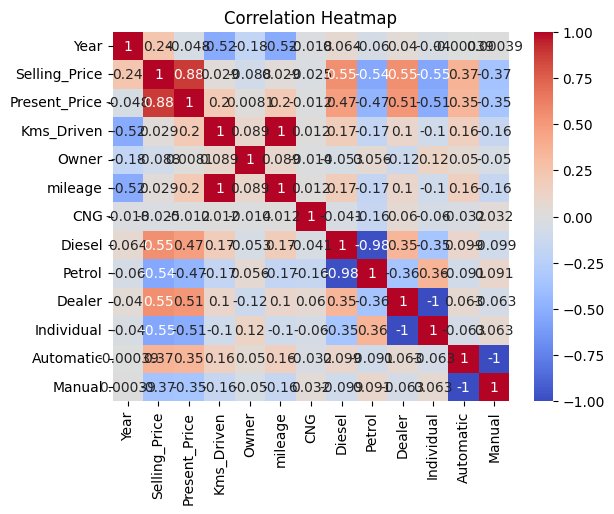

In [ ]:
sns.heatmap(cars.corr(numeric_only=True), annot=True, cmap='coolwarm')  #cars.corr(numeric_only=True) makes sure to select just columns that have numeric data
plt.title('Correlation Heatmap')
plt.show()

**WE CAN NOW GO INTO FEATURE ENGINEERING**
---

**Age of the Car**<br>
creating the Car_Age feature is crucial because it transforms a static categorical variable (Year) into a continuous, interpretable measure of depreciation.<br>
Car age directly captures how long a vehicle has been in use which is a fundamental driver of value loss over time.

In [ ]:
cars['Car_Age'] = 2026 - cars['Year']  #Newer cars usually cost more
display(cars)

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,mileage,CNG,Diesel,Petrol,Dealer,Individual,Automatic,Manual,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224,0.0,0.0,1.0,1.0,0.0,0.0,1.0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911,0.0,1.0,0.0,1.0,0.0,0.0,1.0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969,0.0,0.0,1.0,1.0,0.0,0.0,1.0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758,0.0,0.0,1.0,1.0,0.0,0.0,1.0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743,0.0,1.0,0.0,1.0,0.0,0.0,1.0,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225,0.0,1.0,0.0,1.0,0.0,0.0,1.0,10
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804,0.0,0.0,1.0,1.0,0.0,0.0,1.0,11
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340,0.0,0.0,1.0,1.0,0.0,0.0,1.0,17
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876,0.0,1.0,0.0,1.0,0.0,0.0,1.0,9


**Note**:<br>
This negative correlation between car age and selling price (−0.236) is both expected and highly informative. <br>
It quantifies the depreciation effect, the natural decline in value as a vehicle ages. <br>
In real‑world economics, cars lose value due to wear, technological obsolescence, and reduced buyer appeal.

In [ ]:
cars.Selling_Price.corr(cars.Car_Age) #in  real world, car the year a car was produced is very crucial. 

np.float64(-0.2361409801604276)

Take a look that the distribution of the car mileage (Driven_kms) before **transformation**

In [ ]:
selling_price = px.histogram(cars, x = 'Kms_Driven', title = 'Year vs Selling Price') 
selling_price.update_layout(bargap=0.1) 
selling_price.show()

**Why Did i choose Log transformation over StandardScaler for this data:**
---

The 'Driven_kms' feature was heavily right-skewed, with most cars clustered between *0-100k* but a few outliers stretching all the way to *500*. <br>
StandardScaler **only rescales** the data, it does not change its shape, which implies that those extreme outliers at *300k-500k* would still distort the distribution and pull the model's attention away from where most of the data actually lives. <br>
Log transform on the other hand **compresses large values** aggressively while **spreading out the dense cluster**, fundamentally **reshaping the distribution** into the bell curve you now see between *6-13*. <br>
A bell-shaped distribution is what machine learning models thrive on because the data is evenly spread with no single extreme value dominating the learning process. 
<br> We can visualize this using our histogram which shows how it went from a long-tailed skew to a near-perfect bell, which means your model now has a much fairer and more balanced view of the feature. <br>

imagine you're teaching a student to spot patterns in these numbers:

1,000 <br>
5,000<br>
10,000<br>
500,000 :  this one number dominates everything <br>

The student's eyes keep getting drawn to *500,000* and ignoring the rest. That's exactly what happens to a model
<br> it gets **distracted by the big numbers** and struggles to learn from the smaller ones. <br>

After log transform: <br>
6.9 <br>
8.5<br>
9.2<br>
13.1 : no longer screaming for attention
<br>

Now all values are in a **similar range** and the model can learn from all of them fairly.

**Note**: <br>
On a calculator, the button labeled **“ln”** stands for the natural logarithm, which is exactly what **np.log()** computes in NumPy.

In [ ]:
fstinput = np.log(cars[['Kms_Driven']])
cars['mileage_log'] = np.log(cars['Kms_Driven'])
display(cars)  # after - should look like a bell curve

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,mileage,CNG,Diesel,Petrol,Dealer,Individual,Automatic,Manual,Car_Age,mileage_log
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224,0.0,0.0,1.0,1.0,0.0,0.0,1.0,12,10.203592
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911,0.0,1.0,0.0,1.0,0.0,0.0,1.0,13,10.668955
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969,0.0,0.0,1.0,1.0,0.0,0.0,1.0,9,8.839277
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758,0.0,0.0,1.0,1.0,0.0,0.0,1.0,15,8.556414
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743,0.0,1.0,0.0,1.0,0.0,0.0,1.0,12,10.656082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225,0.0,1.0,0.0,1.0,0.0,0.0,1.0,10,10.433763
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804,0.0,0.0,1.0,1.0,0.0,0.0,1.0,11,11.002100
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340,0.0,0.0,1.0,1.0,0.0,0.0,1.0,17,11.384342
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876,0.0,1.0,0.0,1.0,0.0,0.0,1.0,9,9.104980


In [ ]:
mileage_log = px.histogram(cars, x = 'mileage_log' )
mileage_log.update_layout(bargap=0.1)  
mileage_log.show()

In [ ]:
print(cars.Selling_Price.corr(cars.mileage))
print(cars.Selling_Price.corr(cars.mileage_log))

0.029187090674291306
0.1251925615550675


NOTE: <b> I will use mileage_log since it has a higer correlation <b>

**Before Feeding This Inputs into the Model**
---

Whatever transformation you did to your training data, you must do the same to any new input before prediction. 

```python
import numpy as np

# User inputs raw mileage
new_car_mileage = 45000

# Must convert to log first before feeding to model
new_car_mileage_log = np.log(new_car_mileage)

# Now feed to model
predicted_price = model.predict([[new_car_mileage_log]])
```

**Think of it like a language rule:**
- You trained your model speaking **"log language"**
- If you feed it raw numbers, it's like speaking **English to someone you trained in French** because the answer will be wrong



Car Useage Feature
---
By calculating Car_Age dynamically from the current year, the model avoids hardcoding and remains valid over time, ensuring predictions stay accurate as years progress. <br> 
The car_useage feature, which normalizes mileage by age, introduces a measure of usage intensity, distinguishing between cars that are lightly driven versus those heavily used relative to their age.<br>
This is critical because two cars with identical mileage can have very different wear profiles depending on how long they’ve been on the road. 

In [ ]:
from datetime import datetime

current_year = datetime.now().year #better than Harding coding 2026, cus every new year, the prediction becomes wrong
cars['Car_Age'] = current_year - cars['Year']
cars['car_useage'] = (cars['mileage_log'])/(cars['Car_Age'])
#Calculated the depreciation of the car shows how much value the car has retained
from sklearn.preprocessing import StandardScaler
import pandas as pd

display(cars)



,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,mileage,CNG,Diesel,Petrol,Dealer,Individual,Automatic,Manual,Car_Age,mileage_log,car_useage
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,-0.256224,0.0,0.0,1.0,1.0,0.0,0.0,1.0,12,10.203592,0.850299
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,0.155911,0.0,1.0,0.0,1.0,0.0,0.0,1.0,13,10.668955,0.820689
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,-0.773969,0.0,0.0,1.0,1.0,0.0,0.0,1.0,9,8.839277,0.982142
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,-0.817758,0.0,0.0,1.0,1.0,0.0,0.0,1.0,15,8.556414,0.570428
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,0.141743,0.0,1.0,0.0,1.0,0.0,0.0,1.0,12,10.656082,0.888007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,-0.076225,0.0,1.0,0.0,1.0,0.0,0.0,1.0,10,10.433763,1.043376
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,0.593804,0.0,0.0,1.0,1.0,0.0,0.0,1.0,11,11.002100,1.000191
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,1.313340,0.0,0.0,1.0,1.0,0.0,0.0,1.0,17,11.384342,0.669667
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,-0.719876,0.0,1.0,0.0,1.0,0.0,0.0,1.0,9,9.104980,1.011664


**Observation (Car useage):**
---
This feature captures how real-world car usage patterns directly influence value retention. <br> 
The analysis shows that cars with moderate yearly usage tend to sell for higher prices, while those with very low or very high usage lose value. <br> 
The practical reason is that cars that are rarely driven often develop problems from sitting idle, such as battery drain, rust, or dried seals, while cars driven excessively show heavy mechanical wear. <br>
Buyers therefore prefer vehicles that have been consistently but moderately used, as they signal proper maintenance and balanced wear. <br> 
By engineering this feature (car_useage), the model gains an understanding of depreciation beyond raw mileage or age, improving its ability to predict resale value and making insights more aligned with how buyers actually assess cars in the market.

In [ ]:
CarUseage = px.histogram(cars, y= 'Selling_Price', x = 'car_useage', title = 'Car Useage vs Selling Price') 
CarUseage.update_layout(bargap=0.1) 
CarUseage.show()

In [ ]:
cars[['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'mileage', 'CNG',
       'Diesel', 'Petrol', 'Dealer', 'Individual', 'Automatic', 'Manual',
       'Car_Age', 'mileage_log', 'car_useage' ]].corr()

,Year,Selling_Price,Present_Price,Kms_Driven,mileage,CNG,Diesel,Petrol,Dealer,Individual,Automatic,Manual,Car_Age,mileage_log,car_useage
Year,1.000000,0.236141,-0.047584,-0.524342,-0.524342,-0.017790,0.064315,-0.059959,0.039896,-0.039896,-0.000394,0.000394,-1.000000,-0.545249,0.857487
Selling_Price,0.236141,1.000000,0.878983,0.029187,0.029187,-0.025164,0.552339,-0.540571,0.550724,-0.550724,0.367128,-0.367128,-0.236141,0.125193,0.371111
Present_Price,-0.047584,0.878983,1.000000,0.203647,0.203647,-0.011500,0.473306,-0.465244,0.512030,-0.512030,0.348715,-0.348715,0.047584,0.296159,0.113625
Kms_Driven,-0.524342,0.029187,0.203647,1.000000,1.000000,0.012223,0.172515,-0.172874,0.101419,-0.101419,0.162510,-0.162510,0.524342,0.697632,-0.229429
mileage,-0.524342,0.029187,0.203647,1.000000,1.000000,0.012223,0.172515,-0.172874,0.101419,-0.101419,0.162510,-0.162510,0.524342,0.697632,-0.229429
CNG,-0.017790,-0.025164,-0.011500,0.012223,0.012223,1.000000,-0.040808,-0.160577,0.060300,-0.060300,-0.032018,0.032018,0.017790,0.042825,-0.005412
Diesel,0.064315,0.552339,0.473306,0.172515,0.172515,-0.040808,1.000000,-0.979648,0.350467,-0.350467,0.098643,-0.098643,-0.064315,0.260199,0.209669
Petrol,-0.059959,-0.540571,-0.465244,-0.172874,-0.172874,-0.160577,-0.979648,1.000000,-0.358321,0.358321,-0.091013,0.091013,0.059959,-0.265640,-0.206033
Dealer,0.039896,0.550724,0.512030,0.101419,0.101419,0.060300,0.350467,-0.358321,1.000000,-1.000000,0.063240,-0.063240,-0.039896,0.321632,0.221364
Individual,-0.039896,-0.550724,-0.512030,-0.101419,-0.101419,-0.060300,-0.350467,0.358321,-1.000000,1.000000,-0.063240,0.063240,0.039896,-0.321632,-0.221364


In [ ]:
px.scatter(cars, y = 'Selling_Price', x = 'car_useage')

**Model Selection Strategy for Car Price Prediction**:
---
I will complete this task with Linear Regression as a baseline model to establish a simple relationship between features and selling price. <br> 
Then, i will later test Random Forest and XGBoost, which typically outperform linear models for car price prediction. <br>
Evaluate all models using RMSE to compare accuracy.

For a start, i will use 

Selling Price = M x car_useage + c

**Manual Linear Regression Setup**:<br>
---

Here’s what I did: I manually created a simple linear regression function to estimate car prices before using machine‑learning libraries. <br> 
I defined est_price(estprice, m, c) to calculate predicted selling prices using the formula 𝑌 = 𝑚*𝑋 + 𝑐 (equation of a straight line) <br>
for a start, i set m = 2 (slope) and c = 1 (intercept), then applied it to the car_useage feature to generate estimated prices. <br>
This will allowed me to see how the slope controls the rate of change and the intercept sets the baseline, giving me a clear understanding of how regression works. <br>


In [ ]:
def est_price (estprice, m, c ):   #def is used to define my model
    return m*estprice + c 
m = 2
c = 1            #this is the first model formular (but it also what LinearRegression does)
estprice = cars['car_useage']       #i can now use our desires column here
estimated_price = est_price(estprice, m,c)
display(estimated_price)
    

0      2.700599
1      2.641378
2      2.964284
3      2.140855
4      2.776014
         ...   
296    3.086753
297    3.000382
298    2.339334
299    3.023329
300    2.721187
Name: car_useage, Length: 301, dtype: float64

In [ ]:
display(cars['Selling_Price']) #juat to compare with the actual selling price

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64

In [ ]:
px.scatter(cars, y = estimated_price, x = 'car_useage')  #they have a linear relationship.

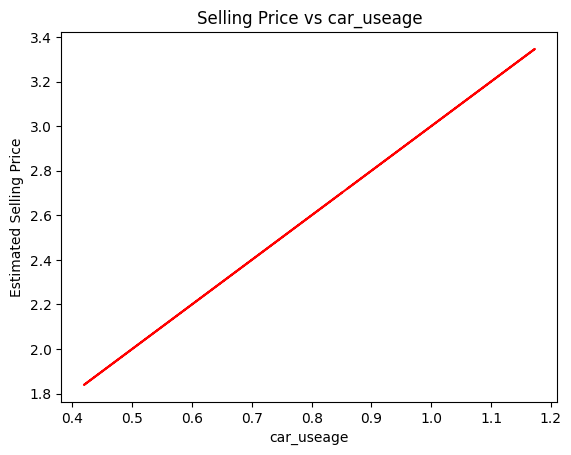

In [ ]:
import matplotlib.pyplot as plt

x = cars['car_useage']      # numeric column
y = estimated_price                  # predicted or target values

plt.plot(x, y, 'r-')   
plt.xlabel('car_useage')
plt.ylabel('Estimated Selling Price')
plt.title('Selling Price vs car_useage')
plt.show()


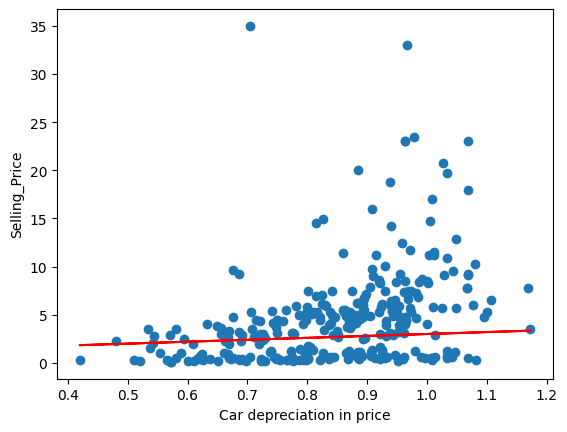

In [ ]:
#target = pd.DataFrame(cars['Selling_Price']) #this is how to convert a single column to a dataframe and work with it
plt.plot(cars['car_useage'], estimated_price , 'r-')
plt.scatter(cars['car_useage'], cars['Selling_Price'])
plt.xlabel('Car depreciation in price')
plt.ylabel('Selling_Price')
plt.show()

**Function for Manual Regression Testing**
---
In the next cell, I wrote a function called try_price(m, c) to experiment with different slope (m) and intercept (c) values for the regression line. The purpose to manually visualize how changes in these parameters affect the fit between predicted and actual car prices.

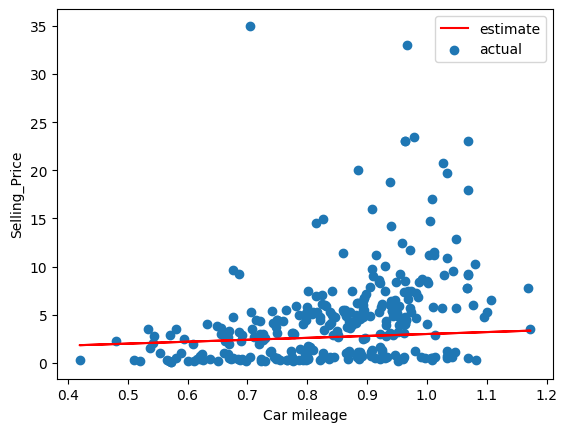

,Predicted,Actual
0,2.700599,3.35
1,2.641378,4.75
2,2.964284,7.25
3,2.140855,2.85
4,2.776014,4.60
...,...,...
296,3.086753,9.50
297,3.000382,4.00
298,2.339334,3.35
299,3.023329,11.50


In [ ]:
estprice = cars['car_useage']

#you can use this function to manually try and fit the line of regression, but it only works for just one feature, not multiple features

def try_price(m, c):
    def est_price(estprice, m, c):
        return m * estprice + c

    estimated_price = est_price(estprice, m, c)

    plt.plot(cars['car_useage'], estimated_price, 'r-')
    plt.scatter(cars['car_useage'], cars['Selling_Price'])
    plt.xlabel('Car mileage')
    plt.ylabel('Selling_Price')
    plt.legend(['estimate', 'actual'])
    plt.show()
    return estimated_price
target = cars['Selling_Price']
comparison = try_price(2,1)   #change the values of try(2,1) to see how close you get to the actual price
sales_forecast = pd.DataFrame({'Predicted': comparison, 'Actual': target}) #The fix is to build the DataFrame from a dict mapping column names to your two series. 
display(sales_forecast)
 

**Importance of RMSE in Model Evaluation** <br>
---
The Root Mean Square Error (RMSE) measures how accurately a model predicts real‑world outcomes by comparing predicted values to actual selling prices. <br>
It provides a clear, interpretable metric of average prediction error in the same units as the target variable, making it easy to understand the model’s performance. <br>
it penalizes large errors more heavily, ensuring that the model doesn’t overlook extreme mispredictions. <br> 
In practice, minimizing RMSE leads to more reliable, market‑aligned forecasts and is a key factor in building trust and precision in pricing models.<br>

Absolut values '|predicted - actual|' can be taken too.<br>
**NOTE** that Outliers have a bigger effect on Square method more than Abosolute Methods because if the gap is too much, the square will also be bigger. However, absolute values just ignores the -ve sign. 

**How the MAE (Mean Absolute Error) Works**
---
E.g.  (4- 9) gives -5. Which means the Square is 25. But Abosolute value just leave it at 5 <br>

**from sklearn.metrics import mean_absolute_error** <br>

Example: actual vs predicted selling prices <br>
y_true = [200000, 150000, 300000, 250000] <br>
y_pred = [210000, 140000, 290000, 260000] <br>

Calculate MAE<br>
**mae = mean_absolute_error(y_true, y_pred)**<br>
print("Mean Absolute Error:", mae)<br>


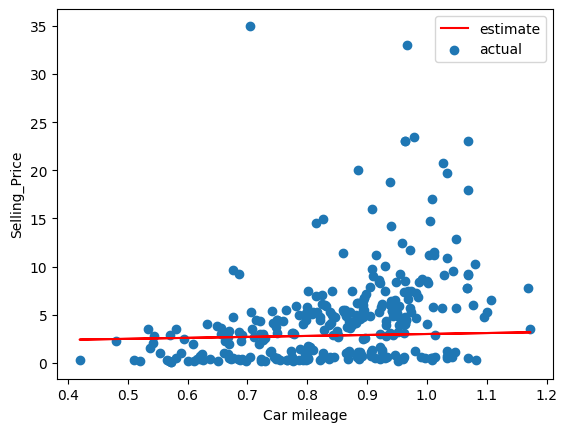

MAE: 3.348099923885947
RMSE: 5.3411755808237205


In [ ]:
from sklearn.metrics import mean_absolute_error
target = cars['Selling_Price']
predictions = try_price(1,2)   #from the 'rmse result' (1,2) is better than (2,1)
def rmse (target, predictions):#dont forget your ':'
      return np.sqrt(np.mean(np.square(target - predictions)))

mae = mean_absolute_error(target,predictions)
print('MAE:', mae)
print('RMSE:',rmse (target, predictions))

**Let us Split the Data**
---
I will select some features like 'Automatic', 'Manual','Dealer', 'Individual','CNG', 'Diesel','Petrol','Car_Age', 'mileage_log', 'car_useage'

In [ ]:
cars.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'mileage', 'CNG',
       'Diesel', 'Petrol', 'Dealer', 'Individual', 'Automatic', 'Manual',
       'Car_Age', 'mileage_log', 'car_useage'],
      dtype='str')

In [ ]:
from sklearn.model_selection import train_test_split

# Select multiple columns as features
x = cars[['Automatic', 'Manual','Dealer', 'Individual','CNG', 'Diesel','Petrol','Car_Age', 'mileage_log', 'car_useage']]   # independent variables    'Automatic', 'Manual',
y = cars['Selling_Price']                        # target variable

# Split into train and test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()   #this is where you define what kind of model you want and what the relationship is

In [ ]:
model = LinearRegression() 
model.fit(x_train, y_train)  #we could have also said LinearRegression.fit(), but we already assinged model= LinearRegression()
#'fit' here will help us determine the best slope 'm' and y-intercept'c' of out regression line.
#it will continue to do all those (2,1) changing and calculate RMSE and give me the result

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
# Predict using your data reserve specifically to test the model
prediction = model.predict(x_test)   #now testing with the data i split to test only

# Combine actual and predicted into a DataFrame
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,    #convert them to Dictionaries a basic way to generating a DataFrame
    "Predicted Sales": prediction     #Our Model Predictions
})

display(comparison)  

def rmse (target, predictions):#dont forget your ':'
      return np.sqrt(np.mean(np.square(target - predictions)))


MAE_error = mean_absolute_error(y_test,prediction)

print('MAE:', MAE_error)

print('RMSE = ', rmse(y_test, prediction))


,Actual Sales,Predicted Sales
0,0.35,6.264278
1,10.11,5.457002
2,4.95,8.689822
3,0.15,-0.746551
4,6.95,3.870742
...,...,...
56,5.50,4.531185
57,9.50,11.041719
58,2.10,3.281766
59,7.40,10.184419


MAE: 2.12871987999286
RMSE =  3.0251661044129032


In [ ]:
coefficient = model.coef_
weight = pd.DataFrame({'Feature': x.columns, 'Coefficient': coefficient})
display(weight)

,Feature,Coefficient
0,Automatic,2.307317
1,Manual,-2.307317
2,Dealer,2.043270
3,Individual,-2.043270
4,CNG,-2.419171
5,Diesel,3.800240
6,Petrol,-1.381069
7,Car_Age,0.540414
8,mileage_log,-1.143386
9,car_useage,15.004049


**Cross Validation:**
---

MAE tells you the average prediction error across folds. <br>

RMSE highlights how well the model handles larger deviations. <br>

In cross-validation, CV=5 means the dataset is split into 5 equal folds. <br>

**The process works like this:<br>**

The model trains on 4 folds and tests on the remaining 1 fold <br>

This repeats 5 times, each time using a different fold as the test set <br>

The final performance score is the average of all 5 test results <br>

The point is to give a more reliable estimate of model performance rather than relying on a single train/test split, which could be lucky or unlucky depending on how the data was divided. <br>

**Note:**<br>
If the **cross‑validated MAE and RMSE** are close to what i got earlier (~2.1 and ~3.0), it means your model is stable and generalizes well. <br>
If they’re much worse, it’s a sign of overfitting and i will try regularization (Ridge/Lasso) or tree‑based models.

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Example: using your selected features
X = cars[['Automatic', 'Manual','Dealer','Individual',
        'CNG','Diesel','Petrol','Car_Age','mileage_log','car_useage']]
y = cars['Selling_Price']

# Initialize model
model = LinearRegression()

# Run cross-validation with MAE and RMSE
mae_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')
rmse_scores = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')

print("Cross-validated MAE:", -np.mean(mae_scores))
print("Cross-validated RMSE:", -np.mean(rmse_scores))

Cross-validated MAE: 2.3750825329180123
Cross-validated RMSE: 3.4072428833450346


my cross‑validated MAE (~2.38) and RMSE (~3.41) are close to my single‑split results (MAE ~2.13, RMSE ~3.03).<br> 
That means your model performs consistently across different subsets of data which is a strong indicator of low variance and good generalization.

In [ ]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)


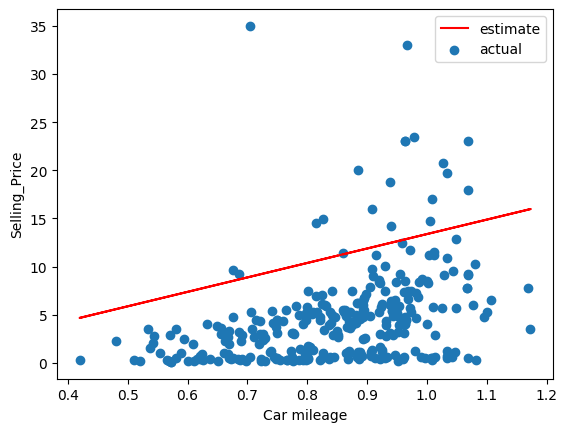

np.float64(7.961930623449801)

In [ ]:
target = cars['Selling_Price']    #this function can only accept on feature at a time
try_predict = try_price(15.00404912,-1.6236590507691755)   #we can now try the values our model used and also visualize the line
def rmse (target, try_predict):#dont forget your ':'
      return np.sqrt(np.mean(np.square(target - try_predict)))


rmse (target, try_predict)

**Moving from Single‑Feature to Multi‑Feature Regression**:
---
When i worked with a single feature, the relationship between that variable and the target can be visualized easily with a straight regression line because it’s a simple two‑dimensional problem. <br>
However, once i introduce multiple features, the model operates in a higher‑dimensional space, meaning i can no longer represent the relationship with a single line.

**Let me Check another model** (RandomForestRegressor)<br>
---

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

rf_model = RandomForestRegressor(
    n_estimators=200,   # number of trees
    max_depth=None,     # let trees grow fully
    random_state=42
)

# Fit on training data
rf_model.fit(x_train, y_train)

# Predict on test data
rf_prediction = rf_model.predict(x_test)

comparison = pd.DataFrame({
    "Actual Sales": y_test.values,    #convert them to Dictionaries a basic way to generating a DataFrame
    "Predicted Sales": rf_prediction     #Our Model Predictions
})

display(comparison)  

def rmse (target, predictions):#dont forget your ':'
      return np.sqrt(np.mean(np.square(target - predictions)))


MAE_error = mean_absolute_error(y_test,rf_prediction)

print('MAE:', MAE_error)

print('RMSE = ', rmse(y_test, rf_prediction))


,Actual Sales,Predicted Sales
0,0.35,0.616650
1,10.11,4.448404
2,4.95,5.540500
3,0.15,0.374550
4,6.95,5.383500
...,...,...
56,5.50,4.501000
57,9.50,12.225400
58,2.10,1.815000
59,7.40,7.831250


MAE: 1.0896730288836853
RMSE =  1.8081347808743857


**This is way better than LinearRegression model** <br>
So, i will complete my task using this model

In [ ]:

X = cars[['Automatic', 'Manual', 'Dealer', 'Individual',
          'CNG', 'Diesel', 'Petrol', 'Car_Age', 'mileage_log', 'car_useage']]
y = cars['Selling_Price']
# Cross-validation for MAE and RMSE
mae_scores = cross_val_score(rf_model, X, y, cv=5, scoring='neg_mean_absolute_error')
rmse_scores = cross_val_score(rf_model, X, y, cv=5, scoring='neg_root_mean_squared_error')

print("Cross-validated MAE:", -np.mean(mae_scores))
print("Cross-validated RMSE:", -np.mean(rmse_scores))


Cross-validated MAE: 1.8445241779913708
Cross-validated RMSE: 2.936637982973887


**Feature Importance in Random Forest**:
---
The feature‑importance plot reveals how each variable contributes to predicting car selling prices. <br>
Diesel stands out as the most influential factor, indicating that fuel type strongly affects resale value <br> 
beacuse diesel vehicles often command higher prices due to their efficiency and durability. <br>

Mileage_log and car_usage follow closely, showing that how much and how long a car has been used directly impacts depreciation. <br>

Dealer and transmission type (Automatic/Manual) also play key roles, reflecting market preferences and seller credibility. <br> 

Meanwhile, Car_Age contributes moderately, as its effect overlaps with mileage, while Petrol and CNG have minimal influence, suggesting their pricing patterns are more stable. 

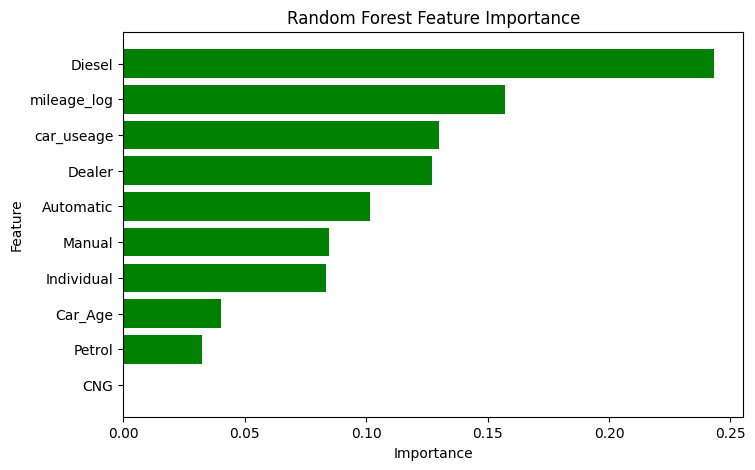

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importances
importances = rf_model.feature_importances_
features = x_train.columns  #gets the names of the column used to train the model as array

# Create a DataFrame for easy plotting
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False) #sort using the 'Importance' column in Decending order

# Plot
plt.figure(figsize=(8,5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='green') #(y axis, x axis, color)

plt.gca().invert_yaxis()  #flips the gragh horizontally (along the y axis)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


**Why plt.barh() Works**
---
**plt.barh()** (horizontal bar chart) expects two arrays or lists: one for the y‑axis categories and one for the x‑axis values. In this case: <br>

importance_df['Feature'] are categorical labels (y‑axis) <br>

importance_df['Importance'] are numeric values (x‑axis) <br>

This pairing fits perfectly with how barh is designed because it plots each feature’s importance horizontally, making it easy to compare across categories. <br>

**Why Other Variants Might Fail**<br>
---
If you tried **plt.bar() or plt.hist()** directly with the same arguments, they wouldn’t work as expected because: <br>

plt.bar() expects numeric x positions, not categorical labels, unless you explicitly convert them (e.g., range(len(features))).<br>

plt.hist() expects a single numeric array to show a distribution, not two arrays for categories and values.<br>

So, plt.barh() works seamlessly because it’s built for categorical comparisons which is exactly what feature importance represents.

**THIS IS BASICALLY THE PRICTION USER INTERFACE** <br>
---
Because it allows you predict the price of any car, given the "year","mileage" and "the type of seller (dealer/owner)"

In [ ]:
import numpy as np
from datetime import datetime

# Collect user input
driven_kms = float(input("Enter the mileage of the car: "))
year = int(input("Enter the year the car was manufactured: "))
fuel_type = input("Enter fuel type (CNG/Diesel/Petrol): ").strip()
transmission = input("Enter transmission type (Automatic/Manual): ").strip() #.strip() removes empty spaces
seller_type = input("Enter seller type (Dealer/Individual): ").strip()

# Calculate derived features
current_year = datetime.now().year
car_age = current_year - year
if car_age == 0:
    car_age = 1

car_mileage = np.log1p(driven_kms)  #have to make a log trasformation before using it.
car_usage = car_mileage / car_age

# Encode categorical features (same encoding used during training)
fuel_CNG = 1 if fuel_type == "CNG" else 0
fuel_Diesel = 1 if fuel_type == "Diesel" else 0
fuel_Petrol = 1 if fuel_type == "Petrol" else 0
trans_Auto = 1 if transmission == "Automatic" else 0
trans_Manual = 1 if transmission == "Manual" else 0
seller_Dealer = 1 if seller_type == "Dealer" else 0
seller_Individual = 1 if seller_type == "Individual" else 0

# Combine all features into a NumPy array
input_data = np.array([[trans_Auto, trans_Manual, seller_Dealer, seller_Individual,
                        fuel_CNG, fuel_Diesel, fuel_Petrol, car_age, car_mileage, car_usage]])

# Predict using your trained Random Forest model
prediction = rf_model.predict(input_data)
print("Predicted value:", prediction[0]) #prediction gives a NumPy array (e.g., [5.72]) while prediction[0] gives single float (e.g., 5.72)


**I predicted the Selling Price of the Third index of this dataframe below**<br>
2.797 was very close to 2.85

In [ ]:
display(cars)

**Instead of intercepts and coefficients,**<br>
---
Random Forest provides: <br>

**Feature Importances (rf_model.feature_importances_)** tells you how much each feature contributes to reducing error across all trees. <br>

**Tree structure (rf_model.estimators_)** helps inspect individual trees if you want to see the exact splits and thresholds. <br>

**Partial Dependence Plots (PDPs)** show how the predicted outcome changes as you vary one feature, holding others constant. <br>

Random Forests trade away simple coefficients for flexibility and accuracy. <br>
If i needed coefficients for interpretability, then i will stick with linear models. <br>
But, i wanted predictive power which made Random Forest a better choice for me.

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 7 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


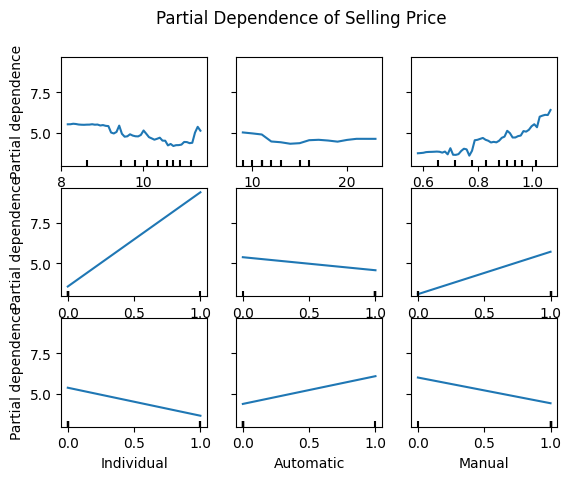

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# Plot partial dependence for mileage_log and Car_Age
features_to_plot = ['mileage_log', 'Car_Age', 'car_useage', 'Diesel', 'Petrol', 'Dealer', 'Individual', 'Automatic', 'Manual' ]

PartialDependenceDisplay.from_estimator(
    rf_model, x_train, features_to_plot,
    kind="average", grid_resolution=50
)

plt.suptitle("Partial Dependence of Selling Price")
plt.show()


**Insights from the Partial Dependence of Selling Price**: <br>
---

the visualiation was arranged like this <br>

'mileage_log',||-'Car_Age',-||'car_useage', <br> 

'Diesel',-------||'Petrol',----||-'Dealer',  <br>

'Individual',---||'Automatic',||-'Manual'<br>


The partial dependence plot reveals how each feature influences the Random Forest model’s prediction of car selling price. <br>

**Mileage_log** and **Car_Age** show a clear negative relationship, indicating that higher mileage and older cars reduce value. <br>

**Car_usage** demonstrates a positive trend, suggesting that efficient or consistent usage may correlate with better resale prices.<br>

Among categorical features, **Diesel vehicles** command higher predicted prices compared to **Petrol**, reflecting their durability and fuel economy. <br> 

**Dealer listings** tend to yield higher prices than **Individual sellers**, likely due to trust and warranty factors. <br>

**Transmission type** also plays a role because **Manual cars** slightly increase predicted value, while **Automatic ones** show a mild decline. <br> 

In summary, the model captures realistic market dynamics, emphasizing depreciation with age and mileage while highlighting categorical factors that influence buyer perception and pricing.

In [ ]:
import shap
import matplotlib.pyplot as plt

# Initialize SHAP explainer for the Random Forest model
explainer = shap.TreeExplainer(rf_model)

# Compute SHAP values my training data
shap_values = explainer.shap_values(x_train)

plt.title("SHAP Feature Importance (Global Impact)")
plt.show()

shap.summary_plot(shap_values, x_train)


**Interpretation of the SHAP Summary Plot**
---
This SHAP summary plot provides a clear visualization of how each feature influences the Random Forest model’s predictions for car selling price. <br>
Features such as Diesel, Dealer, and car_usage have the strongest positive SHAP values, meaning higher values for these features push the predicted price upward.<br>
Conversely, features like Individual, Petrol, and CNG show negative SHAP values, indicating they tend to lower the predicted price.

So -1 is just a shortcut that adapts to whatever length your array has. If tomorrow you had 100 <br> predictions, reshape(-1, 1) would give (100, 1) without you needing to change the code.<br>

Why not just 1?<br>
If you wrote reshape(1, 1), NumPy would force the array into exactly 1 row and 1 column, which only <br>
works if your array has exactly 1 element. For 50 elements, it would throw an error because the <br>sizes don’t match.

In [ ]:
display(cars)